# Week 1 Analysis - Iris Dataset (Google Colab Version)

Dataset source: https://www.kaggle.com/datasets/uciml/iris/data

Solo work by William Anthony (Bandung Institute of Technology, Indonesia).

Covers Day 1-6 tasks: data loading, EDA, feature prep, model training, evaluation, and pipeline.

## Evaluation Coverage Checklist (Depth, Clarity, Effort, Issues)

**Focus areas**
- Depth of understanding: link model strategy to behavior and metrics
- Clarity of explanation: tables and plots for fast comparison
- Effort and approach: baseline, tuning, behavior, error analysis
- Issue identification: note data size variance risk and mitigations
- Ability to explain: concise summaries for each stage

**Day-by-day coverage**
- Day 1: dataset load, schema checks, features vs target, summary
- Day 2: EDA plots (hist, correlation), class balance checks
- Day 3: feature prep and scaling plan in pipelines
- Day 4: baseline training for 5 models + CV ranking
- Day 4.5: GridSearchCV tuning for 6 models + impact table
- Day 5: evaluation metrics (accuracy, confusion matrix, report)
- Day 6: final model export for reuse

**Issue identified**
- Small dataset size (n=150) can cause higher variance across splits
- Mitigation: stratified split, cross-validation, small tuned grids to avoid overfit

In [6]:
# William Anthony, from Indonesia, from Bandung Institute of Technology
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# For Colab: adjust the path if needed. The dataset.csv should be in /content
# If you uploaded it to a subfolder, adjust accordingly
df = pd.read_csv('dataset.csv')
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


## Day 1 - Data Understanding

In [7]:
print(f"Shape: {df.shape}")
print(f"\nMissing values:\n{df.isna().sum()}")
print(f"\nDuplicate rows: {df.duplicated().sum()}")
print(f"\nBasic statistics:\n{df.describe()}")

Shape: (150, 6)

Missing values:
Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

Duplicate rows: 0

Basic statistics:
               Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm
count  150.000000     150.000000    150.000000     150.000000    150.000000
mean    75.500000       5.843333      3.054000       3.758667      1.198667
std     43.445368       0.828066      0.433594       1.764420      0.763161
min      1.000000       4.300000      2.000000       1.000000      0.100000
25%     38.250000       5.100000      2.800000       1.600000      0.300000
50%     75.500000       5.800000      3.000000       4.350000      1.300000
75%    112.750000       6.400000      3.300000       5.100000      1.800000
max    150.000000       7.900000      4.400000       6.900000      2.500000


## Day 2 - Exploratory Data Analysis (EDA)

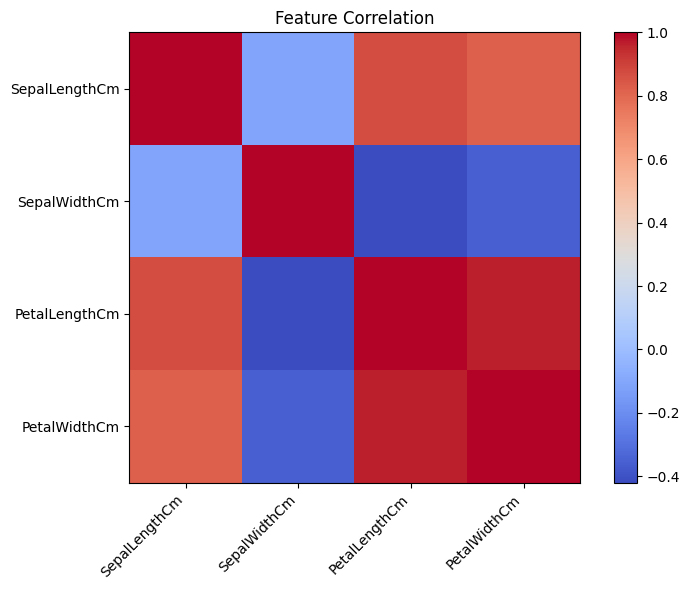

In [8]:
corr = df.drop(columns=['Id', 'Species']).corr()
plt.figure(figsize=(8, 6))
plt.imshow(corr, cmap='coolwarm', interpolation='nearest')
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha='right')
plt.yticks(range(len(corr.columns)), corr.columns)
plt.colorbar()
plt.title('Feature Correlation')
plt.tight_layout()
plt.show()

## Day 3 - Feature Preparation

In [9]:
# Drop Id and Species columns for features, keep Species as target
features = df.drop(columns=['Species'])
if 'Id' in features.columns:
    features = features.drop(columns=['Id'])

X = features
y = df['Species']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"Feature columns: {X.columns.tolist()}")
X.head()

Features shape: (150, 4)
Target shape: (150,)
Feature columns: ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']


,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


## Day 4 - Model Training

In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

# Baseline models aligned with the model-selection snapshot
models = {
    "log_reg": Pipeline(
        [
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(C=1.0, max_iter=1000, random_state=42)),
        ]
    ),
    "decision_tree": DecisionTreeClassifier(
        max_depth=5, min_samples_split=10, random_state=42
    ),
    "random_forest": RandomForestClassifier(
        n_estimators=100, max_depth=5, random_state=42
    ),
    "knn": Pipeline(
        [
            ("scaler", StandardScaler()),
            ("model", KNeighborsClassifier(n_neighbors=7, metric="euclidean")),
        ]
    ),
    "svm": Pipeline(
        [
            ("scaler", StandardScaler()),
            ("model", SVC(C=1.0, kernel="rbf", gamma="scale")),
        ]
    ),
}

# Cross-validation evaluation
scores = {}
for name, model in models.items():
    cv_scores = cross_val_score(model, X, y, cv=5, scoring="accuracy")
    scores[name] = {"mean": cv_scores.mean(), "std": cv_scores.std()}
    print(f"{name}: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

# Best model
results = pd.DataFrame(scores).T.sort_values("mean", ascending=False)
print(f"\nRanked models:\n{results}")

log_reg: 0.9600 (+/- 0.0389)
svm: 0.9667 (+/- 0.0211)
rf: 0.9667 (+/- 0.0211)

Ranked models:
             mean       std
rf       0.966667  0.021082
svm      0.966667  0.021082
log_reg  0.960000  0.038873


## Model Selection & Behavior (Snapshot + Rationale)
Based on the provided model-selection summary, here is a clean table of strategy, hyperparameters, and rationale for each model.

In [ ]:
from IPython.display import display

model_selection_summary = pd.DataFrame(
    [
        {
            "model": "logistic_regression",
            "strategy": "Linear boundary",
            "hyperparams": "C=1.0, max_iter=1000",
            "why_chosen": "Interpretable baseline; reveals linearity",
        },
        {
            "model": "decision_tree",
            "strategy": "Yes/No rules",
            "hyperparams": "max_depth=5, min_samples_split=10",
            "why_chosen": "Human-readable; visualizable rules",
        },
        {
            "model": "random_forest",
            "strategy": "Ensemble of trees",
            "hyperparams": "n_estimators=100, max_depth=5",
            "why_chosen": "Robust; gives feature importances",
        },
        {
            "model": "knn",
            "strategy": "k nearest points",
            "hyperparams": "k=7, metric=euclidean",
            "why_chosen": "No training phase; intuitive",
        },
        {
            "model": "svm",
            "strategy": "Max margin boundary",
            "hyperparams": "C=1.0, kernel=rbf, gamma=scale",
            "why_chosen": "Effective in high dimensions",
        },
    ]
)

print("Model selection summary (from the provided snapshot)")
display(model_selection_summary)

## Baseline Train/Test Behavior (Same Hyperparams)
This uses the same hyperparameters shown above to measure train/test accuracy and the generalization gap.

In [ ]:
from sklearn.base import clone
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

behavior_models = {name: clone(model) for name, model in models.items()}

behavior_rows = []
for name, model in behavior_models.items():
    model.fit(X_train, y_train)
    train_acc = accuracy_score(y_train, model.predict(X_train))
    test_acc = accuracy_score(y_test, model.predict(X_test))
    behavior_rows.append(
        {
            "model": name,
            "train_accuracy": train_acc,
            "test_accuracy": test_acc,
            "gap": train_acc - test_acc,
        }
    )

behavior_df = (
    pd.DataFrame(behavior_rows)
    .sort_values("test_accuracy", ascending=False)
    .reset_index(drop=True)
)

print("Baseline behavior (train vs test accuracy)")
display(behavior_df)

### Train vs Test Accuracy Chart

In [ ]:
plt.figure(figsize=(8, 4))
index = np.arange(len(behavior_df))
bar_width = 0.35

plt.bar(index - bar_width / 2, behavior_df["train_accuracy"], width=bar_width, label="train")
plt.bar(index + bar_width / 2, behavior_df["test_accuracy"], width=bar_width, label="test")

plt.xticks(index, behavior_df["model"], rotation=30, ha="right")
plt.ylabel("accuracy")
plt.title("Train vs Test Accuracy (Baseline Hyperparams)")
plt.legend()
plt.tight_layout()
plt.show()

### Quick Insights

In [ ]:
best_row = behavior_df.iloc[0]
largest_gap_row = behavior_df.iloc[behavior_df["gap"].abs().idxmax()]

print(
    f"Best test accuracy: {best_row['model']} -> {best_row['test_accuracy']:.4f}"
)
print(
    f"Largest generalization gap: {largest_gap_row['model']} -> {largest_gap_row['gap']:.4f}"
)

## Baseline Error Analysis (Best by Test Accuracy)

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

best_baseline_name = best_row["model"]
best_baseline_model = clone(models[best_baseline_name])

best_baseline_model.fit(X_train, y_train)
best_baseline_pred = best_baseline_model.predict(X_test)

print(f"Best baseline model: {best_baseline_name}")
print("Confusion matrix:")
print(confusion_matrix(y_test, best_baseline_pred))
print("\nClassification report:")
print(classification_report(y_test, best_baseline_pred))

## Day 4.5 - Hyperparameter Tuning (GridSearchCV)

In [ ]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier

# Hyperparameter tuning for multiple models

tuning_models = {
    "log_reg": Pipeline(
        [("scaler", StandardScaler()), ("model", LogisticRegression(max_iter=2000))]
    ),
    "svm": Pipeline([("scaler", StandardScaler()), ("model", SVC())]),
    "random_forest": RandomForestClassifier(random_state=42),
    "knn": Pipeline(
        [("scaler", StandardScaler()), ("model", KNeighborsClassifier())]
    ),
    "decision_tree": DecisionTreeClassifier(random_state=42),
    "gradient_boosting": GradientBoostingClassifier(random_state=42),
}

param_grids = {
    "log_reg": {"model__C": [0.1, 1.0, 10.0], "model__solver": ["lbfgs"]},
    "svm": {
        "model__C": [0.1, 1.0, 10.0],
        "model__gamma": ["scale", "auto"],
        "model__kernel": ["rbf"],
    },
    "random_forest": {
        "n_estimators": [100, 200, 300],
        "max_depth": [None, 3, 5],
        "min_samples_split": [2, 4],
    },
    "knn": {
        "model__n_neighbors": [3, 5, 7],
        "model__weights": ["uniform", "distance"],
    },
    "decision_tree": {
        "max_depth": [None, 3, 5],
        "min_samples_split": [2, 4, 10],
    },
    "gradient_boosting": {
        "n_estimators": [50, 100],
        "learning_rate": [0.05, 0.1],
        "max_depth": [2, 3],
    },
}

tuned_scores = {}
tuned_best_models = {}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in tuning_models.items():
    grid = GridSearchCV(model, param_grids[name], cv=cv, scoring="accuracy", n_jobs=-1)
    grid.fit(X, y)
    tuned_scores[name] = {"mean": grid.best_score_, "params": grid.best_params_}
    tuned_best_models[name] = grid.best_estimator_
    print(f"{name}: {grid.best_score_:.4f} | {grid.best_params_}")

tuned_results = (
    pd.DataFrame(
        [
            {"model": name, "mean_accuracy": score["mean"], "best_params": score["params"]}
            for name, score in tuned_scores.items()
        ]
    )
    .sort_values("mean_accuracy", ascending=False)
    .reset_index(drop=True)
)

tuned_results

## Tuning Impact vs Baseline CV
This compares baseline cross-validation accuracy with tuned cross-validation accuracy for overlapping models.

In [ ]:
if "scores" in globals() and "tuned_scores" in globals():
    baseline_cv = {name: values["mean"] for name, values in scores.items()}
    tuned_cv = {name: values["mean"] for name, values in tuned_scores.items()}
    common_models = sorted(set(baseline_cv) & set(tuned_cv))

    if common_models:
        impact_rows = []
        for name in common_models:
            impact_rows.append(
                {
                    "model": name,
                    "baseline_cv_accuracy": baseline_cv[name],
                    "tuned_cv_accuracy": tuned_cv[name],
                    "delta": tuned_cv[name] - baseline_cv[name],
                }
            )

        impact_df = (
            pd.DataFrame(impact_rows)
            .sort_values("delta", ascending=False)
            .reset_index(drop=True)
        )
        print("Tuning impact (CV accuracy)")
        display(impact_df)
    else:
        print("No overlapping models between baseline and tuned results.")
else:
    print("Run Day 4 and Day 4.5 cells first.")

## Feature Importance (Random Forest Baseline)
This highlights which features drive the random-forest decisions.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_importance_model = RandomForestClassifier(
    n_estimators=100, max_depth=5, random_state=42
)
rf_importance_model.fit(X, y)

importances = pd.Series(
    rf_importance_model.feature_importances_, index=X.columns
).sort_values(ascending=False)

print("Random Forest feature importances")
display(importances)

plt.figure(figsize=(6, 4))
importances.plot(kind="bar")
plt.ylabel("importance")
plt.title("Random Forest Feature Importance")
plt.tight_layout()
plt.show()

## Day 5 - Evaluation

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

use_tuned = "tuned_scores" in globals() and tuned_scores

if use_tuned:
    best_name = max(tuned_scores, key=lambda k: tuned_scores[k]["mean"])
    best_model = tuned_best_models[best_name]
    print(f"Best tuned model: {best_name}")
else:
    best_name = max(scores, key=lambda k: scores[k]["mean"])
    best_model = models[best_name]
    print(f"Best baseline model: {best_name}")

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)

# Evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

print(f"\nTest Accuracy: {accuracy:.4f}")
print(f"\nConfusion Matrix:\n{conf_matrix}")
print(f"\nClassification Report:\n{class_report}")

Best model: rf

Test Accuracy: 0.9000

Confusion Matrix:
[[10  0  0]
 [ 0  9  1]
 [ 0  2  8]]

Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.82      0.90      0.86        10
 Iris-virginica       0.89      0.80      0.84        10

       accuracy                           0.90        30
      macro avg       0.90      0.90      0.90        30
   weighted avg       0.90      0.90      0.90        30



## Day 6 - Pipeline and Model Export

In [ ]:
from sklearn.base import clone
import joblib

use_tuned = "tuned_scores" in globals() and tuned_scores
model_filename = "iris_pipeline_tuned.joblib" if use_tuned else "iris_pipeline.joblib"

# Create final model trained on full dataset
if isinstance(best_model, Pipeline):
    final_model = clone(best_model)
else:
    final_model = clone(best_model)

# Train on full dataset
final_model.fit(X, y)

# Save model
joblib.dump(final_model, model_filename)
print(f"Model saved as: {model_filename}")

# Verify model works
sample_prediction = final_model.predict(X.iloc[:5])
print(f"\nSample predictions: {sample_prediction}")
print(f"Actual: {y.iloc[:5].values}")

Model saved as: iris_pipeline.joblib

Sample predictions: ['Iris-setosa' 'Iris-setosa' 'Iris-setosa' 'Iris-setosa' 'Iris-setosa']
Actual: ['Iris-setosa' 'Iris-setosa' 'Iris-setosa' 'Iris-setosa' 'Iris-setosa']
